# Real-Time RQNN + EKF Drift Analysis
Comprehensive analysis of the live rosbag test. We evaluate the zero-lag RQNN filter on multiple raw sensor streams (IMU, Wheel Odometry, Visual Odometry) and quantify the final positional drift of the EKF.

In [13]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message
from sensor_msgs.msg import NavSatFix, Imu
from nav_msgs.msg import Odometry
import math

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['lines.linewidth'] = 2.0

In [14]:
def get_latest_bag(bag_prefix="/home/rosdata/rosbags/moving_bot_live_test_"):
    bags = sorted(glob.glob(f"{bag_prefix}*"))
    if not bags:
        raise ValueError("No rosbags found!")
    return bags[-1]

BAG_PATH = get_latest_bag()
print(f"Analyzing Bag: {BAG_PATH}")

Analyzing Bag: /home/rosdata/rosbags/moving_bot_live_test_20260410_225950


In [15]:
def load_bag(bag_path):
    storage_options = rosbag2_py.StorageOptions(uri=bag_path, storage_id='sqlite3')
    converter_options = rosbag2_py.ConverterOptions(
        input_serialization_format='cdr', output_serialization_format='cdr')
    reader = rosbag2_py.SequentialReader()
    reader.open(storage_options, converter_options)

    TOPICS = {
        '/odometry/local': ('local_ekf', Odometry),
        '/odometry/global': ('global_ekf', Odometry),
        '/diff_drive_controller/odom': ('raw_wheel', Odometry),
        '/diff_drive_controller/odom/filtered': ('rqnn_wheel', Odometry),
        '/odometry/visual': ('raw_visual', Odometry),
        '/odometry/visual/filtered': ('rqnn_visual', Odometry),
        '/imu/data': ('raw_imu', Imu),
        '/imu/data/filtered': ('rqnn_imu', Imu)
    }

    data = {k: [] for k, _ in TOPICS.values()}

    while reader.has_next():
        topic, msg_data, timestamp = reader.read_next()
        if topic in TOPICS:
            name, msg_type = TOPICS[topic]
            msg = deserialize_message(msg_data, msg_type)
            t = msg.header.stamp.sec + msg.header.stamp.nanosec * 1e-9
            
            if msg_type == Odometry:
                row = {'time': t, 'x': msg.pose.pose.position.x, 'y': msg.pose.pose.position.y,
                       'vx': msg.twist.twist.linear.x, 'wz': msg.twist.twist.angular.z}
            elif msg_type == Imu:
                row = {'time': t, 'ax': msg.linear_acceleration.x, 'gx': msg.angular_velocity.x}
                
            data[name].append(row)

    dfs = {}
    for name, rows in data.items():
        if rows:
            df = pd.DataFrame(rows)
            df['time'] -= df['time'].min()
            dfs[name] = df
            
    return dfs

dfs = load_bag(BAG_PATH)
print("Loaded data for:", list(dfs.keys()))

[INFO] [1775842834.736001667] [rosbag2_storage]: Opened database '/home/rosdata/rosbags/moving_bot_live_test_20260410_225950/moving_bot_live_test_20260410_225950_0.db3' for READ_ONLY.


Loaded data for: ['local_ekf', 'global_ekf', 'raw_wheel', 'rqnn_wheel', 'raw_visual', 'rqnn_visual', 'raw_imu', 'rqnn_imu']


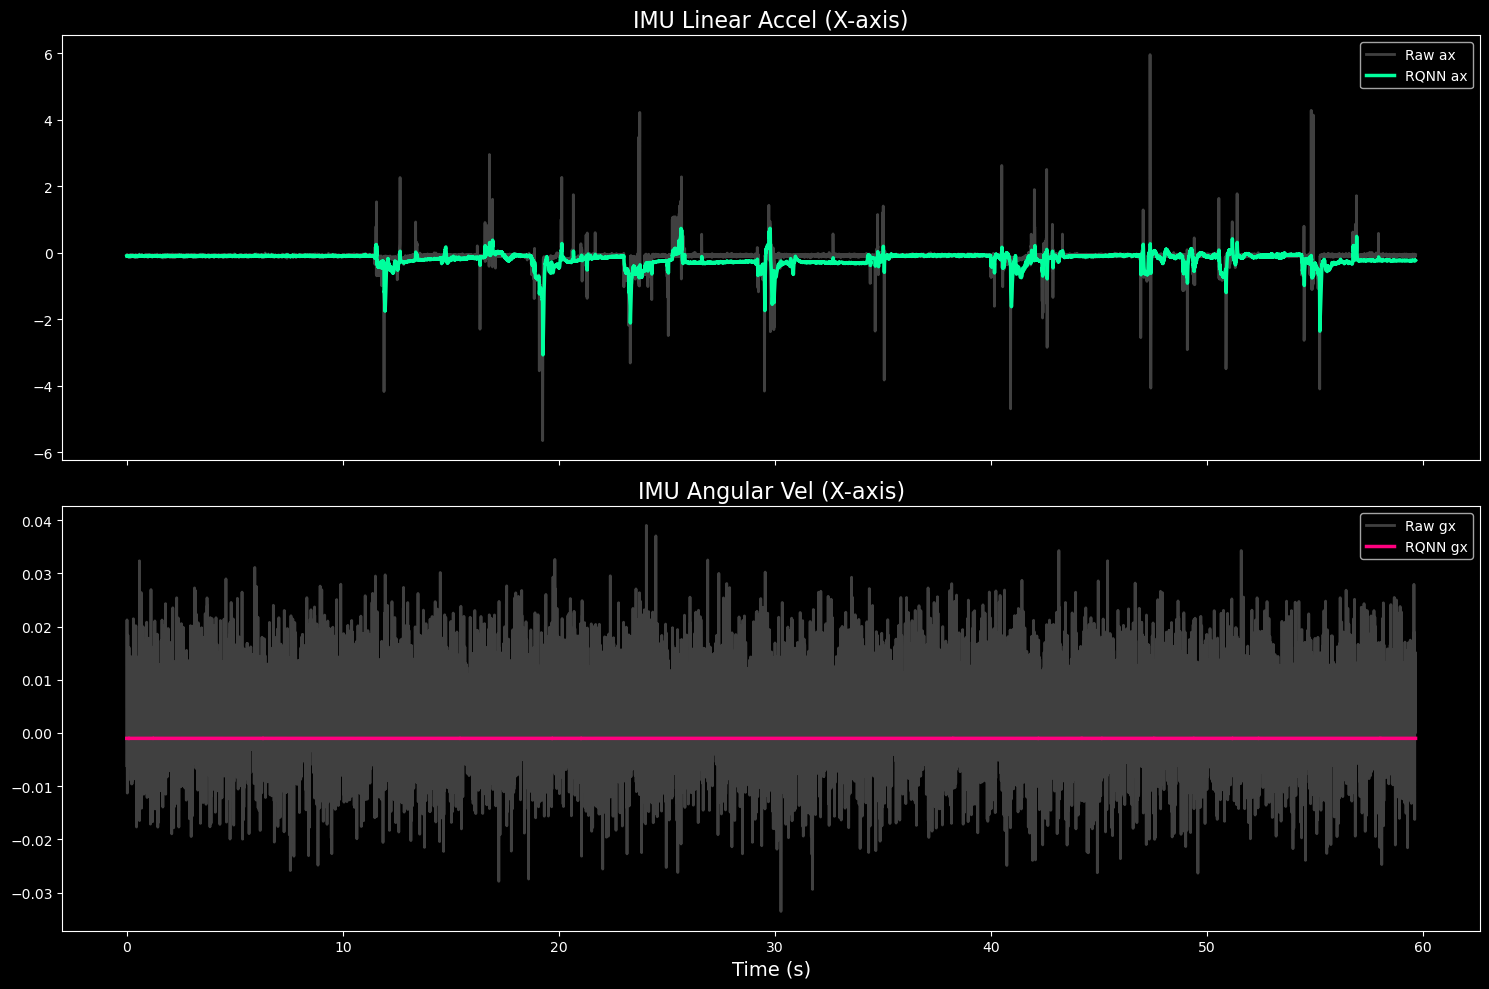

In [16]:
# 1. IMU Zero-Lag Filtering
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

if 'raw_imu' in dfs and 'rqnn_imu' in dfs:
    r_imu, f_imu = dfs['raw_imu'], dfs['rqnn_imu']
    ax1.plot(r_imu['time'].to_numpy(), r_imu['ax'].to_numpy(), color='gray', alpha=0.5, label='Raw ax')
    ax1.plot(f_imu['time'].to_numpy(), f_imu['ax'].to_numpy(), color='#00ff9d', linewidth=2.5, label='RQNN ax')
    ax1.set_title('IMU Linear Accel (X-axis)', fontsize=16, color='white')
    ax1.legend()
    
    ax2.plot(r_imu['time'].to_numpy(), r_imu['gx'].to_numpy(), color='gray', alpha=0.5, label='Raw gx')
    ax2.plot(f_imu['time'].to_numpy(), f_imu['gx'].to_numpy(), color='#ff007f', linewidth=2.5, label='RQNN gx')
    ax2.set_title('IMU Angular Vel (X-axis)', fontsize=16, color='white')
    ax2.set_xlabel('Time (s)', fontsize=14, color='white')
    ax2.legend()
plt.tight_layout()
plt.show()

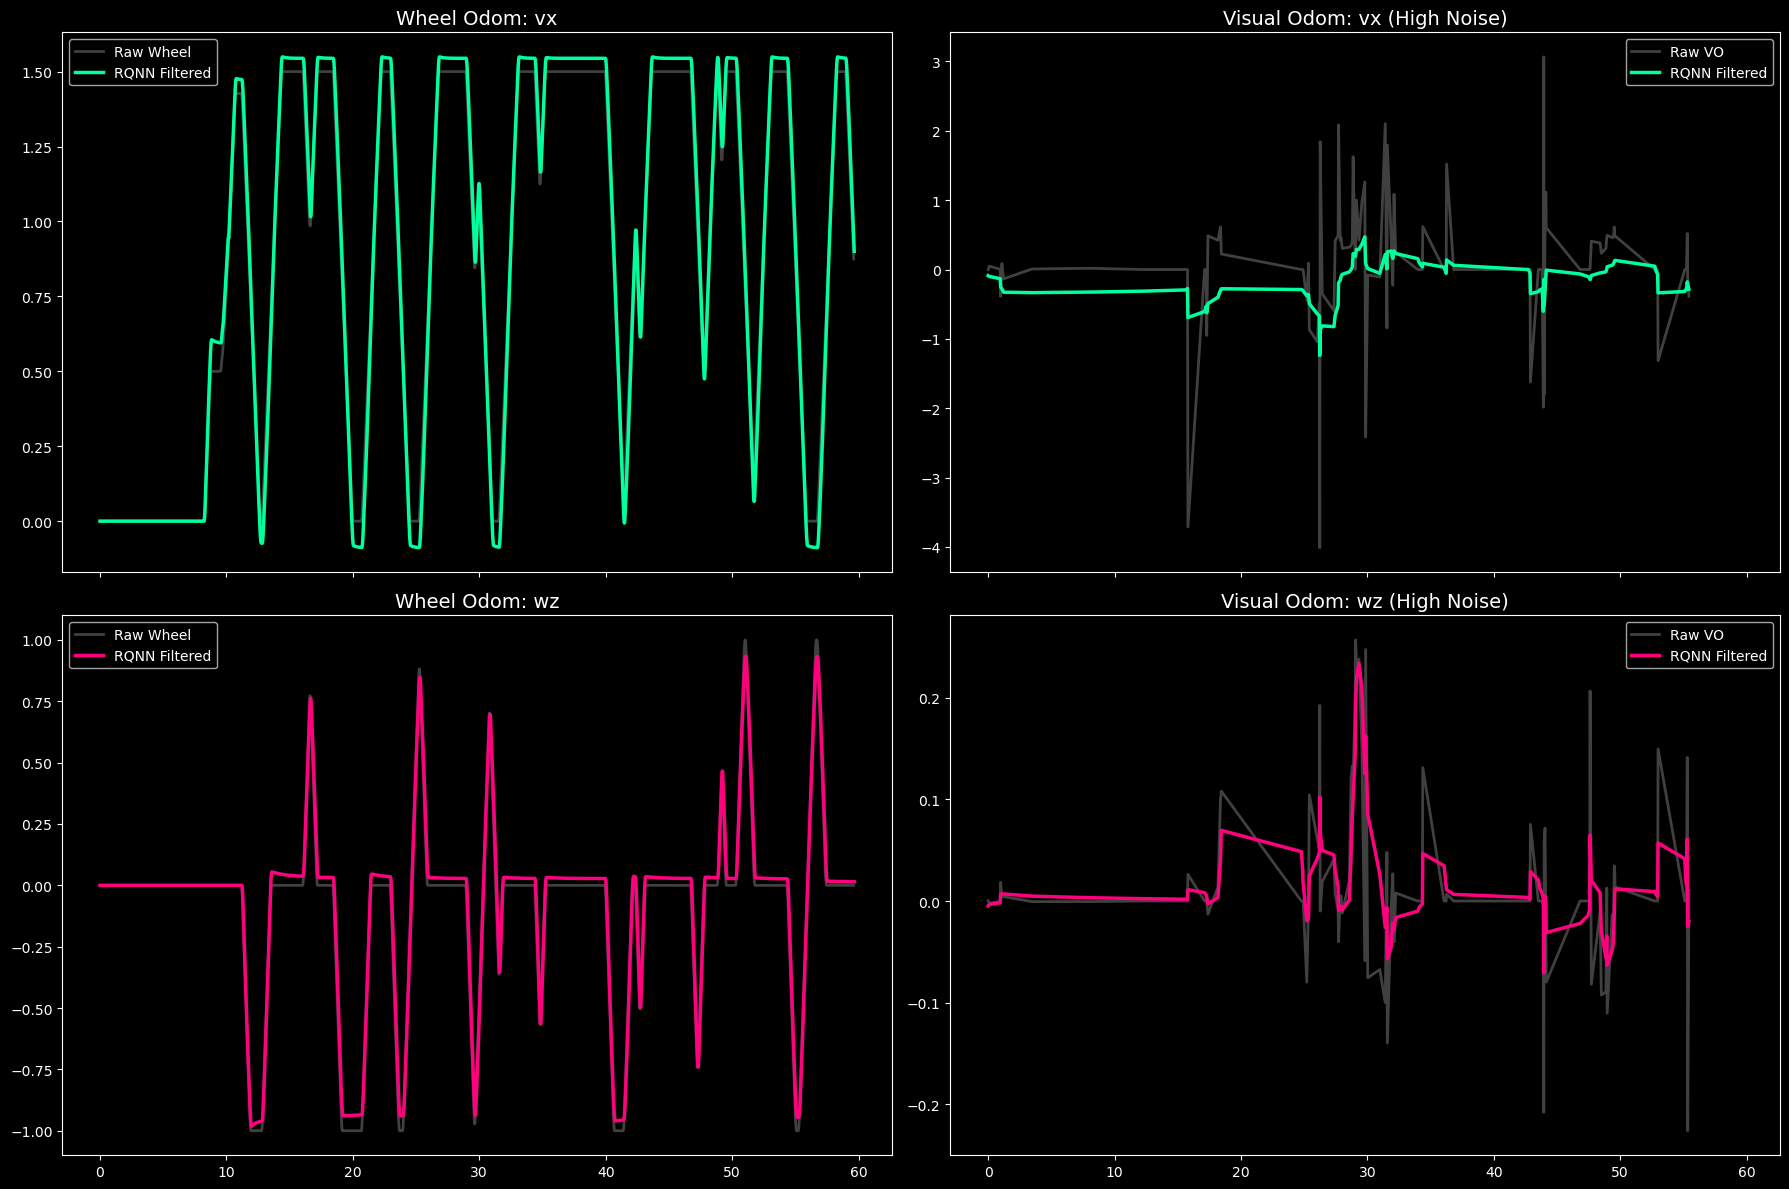

In [17]:
# 2. Odometry Zero-Lag Filtering
fig, axs = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
if 'raw_wheel' in dfs:
    r_wh, f_wh = dfs['raw_wheel'], dfs['rqnn_wheel']
    axs[0,0].plot(r_wh['time'].to_numpy(), r_wh['vx'].to_numpy(), color='gray', alpha=0.5, label='Raw Wheel')
    axs[0,0].plot(f_wh['time'].to_numpy(), f_wh['vx'].to_numpy(), color='#00ff9d', linewidth=2.5, label='RQNN Filtered')
    axs[0,0].set_title('Wheel Odom: vx', color='white', fontsize=14)
    axs[0,0].legend()

    axs[1,0].plot(r_wh['time'].to_numpy(), r_wh['wz'].to_numpy(), color='gray', alpha=0.5, label='Raw Wheel')
    axs[1,0].plot(f_wh['time'].to_numpy(), f_wh['wz'].to_numpy(), color='#ff007f', linewidth=2.5, label='RQNN Filtered')
    axs[1,0].set_title('Wheel Odom: wz', color='white', fontsize=14)
    axs[1,0].legend()

if 'raw_visual' in dfs:
    r_vo, f_vo = dfs['raw_visual'], dfs['rqnn_visual']
    axs[0,1].plot(r_vo['time'].to_numpy(), r_vo['vx'].to_numpy(), color='gray', alpha=0.5, label='Raw VO')
    axs[0,1].plot(f_vo['time'].to_numpy(), f_vo['vx'].to_numpy(), color='#00ff9d', linewidth=2.5, label='RQNN Filtered')
    axs[0,1].set_title('Visual Odom: vx (High Noise)', color='white', fontsize=14)
    axs[0,1].legend()

    axs[1,1].plot(r_vo['time'].to_numpy(), r_vo['wz'].to_numpy(), color='gray', alpha=0.5, label='Raw VO')
    axs[1,1].plot(f_vo['time'].to_numpy(), f_vo['wz'].to_numpy(), color='#ff007f', linewidth=2.5, label='RQNN Filtered')
    axs[1,1].set_title('Visual Odom: wz (High Noise)', color='white', fontsize=14)
    axs[1,1].legend()
    
plt.tight_layout()
plt.show()

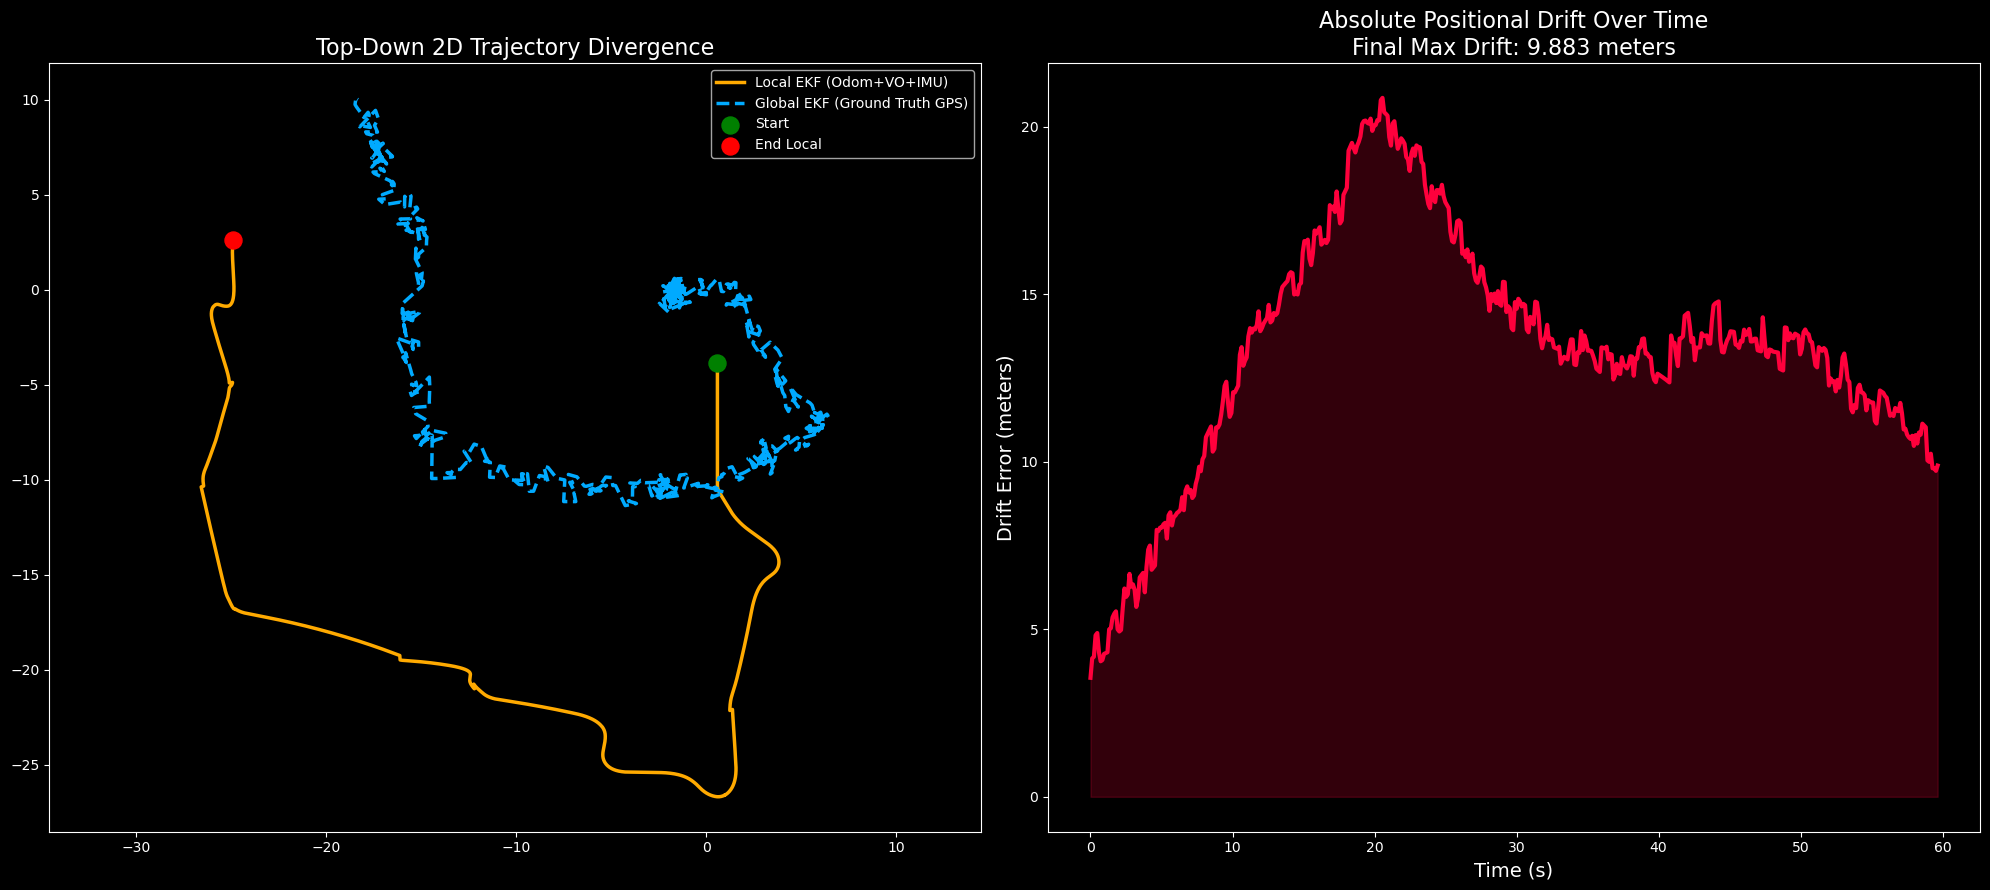

In [18]:
# 3. EKF Drift Over Time & Map
fig, (ax_map, ax_drift) = plt.subplots(1, 2, figsize=(20, 9))
if 'local_ekf' in dfs and 'global_ekf' in dfs:
    loc = dfs['local_ekf']
    glob = dfs['global_ekf']
    
    # Map
    ax_map.plot(loc['x'].to_numpy(), loc['y'].to_numpy(), label='Local EKF (Odom+VO+IMU)', color='#ffaa00', linewidth=2.5)
    ax_map.plot(glob['x'].to_numpy(), glob['y'].to_numpy(), label='Global EKF (Ground Truth GPS)', color='#00aaff', linewidth=2.5, linestyle='--')
    ax_map.scatter([loc['x'].iloc[0]], [loc['y'].iloc[0]], color='green', s=150, zorder=5, label='Start')
    ax_map.scatter([loc['x'].iloc[-1]], [loc['y'].iloc[-1]], color='red', s=150, zorder=5, label='End Local')
    ax_map.set_title('Top-Down 2D Trajectory Divergence', fontsize=16, color='white')
    ax_map.legend()
    ax_map.axis('equal')
    
    # Note: local & global might have different lengths/timestamps. Interpolate to calculate instantaneous drift.
    t_min = max(loc['time'].min(), glob['time'].min())
    t_max = min(loc['time'].max(), glob['time'].max())
    times = np.linspace(t_min, t_max, 500)
    
    loc_x_interp = np.interp(times, loc['time'].to_numpy(), loc['x'].to_numpy())
    loc_y_interp = np.interp(times, loc['time'].to_numpy(), loc['y'].to_numpy())
    glob_x_interp = np.interp(times, glob['time'].to_numpy(), glob['x'].to_numpy())
    glob_y_interp = np.interp(times, glob['time'].to_numpy(), glob['y'].to_numpy())
    
    instant_drift = np.sqrt((loc_x_interp - glob_x_interp)**2 + (loc_y_interp - glob_y_interp)**2)
    
    ax_drift.plot(times, instant_drift, color='#ff003c', linewidth=3)
    ax_drift.fill_between(times, instant_drift, color='#ff003c', alpha=0.2)
    ax_drift.set_title(f'Absolute Positional Drift Over Time\nFinal Max Drift: {instant_drift[-1]:.3f} meters', fontsize=16, color='white')
    ax_drift.set_xlabel('Time (s)', fontsize=14, color='white')
    ax_drift.set_ylabel('Drift Error (meters)', fontsize=14, color='white')
    
plt.tight_layout()
plt.savefig('ekf_drift_overview.png', facecolor='black')
plt.show()